# Facial Recognition System

## 1. Environment and Dependencies
This notebook requires Python 3.7 and the dependencies listed in the provided `environment.yml` file.

The recommended installation method is:

```bash
conda env create -f environment.yml
conda activate facial-recognition
```
Alternatively, the required packages can be installed manually using the instructions in the README.md.

----------------------------------------------------------------------------------------------------------

<div class="alert alert-block alert-info">
<b>IMPORTANT:</b> Before running this notebook, make sure the environment is configured and follow the data download and setup instructions provided in the README.md.
</div>

<div class="alert alert-block alert-danger">
<b>Note:</b> If you are running this notebook on WSL2, please follow the instructions in `README.md` (Section 3.2) to capture anchor/positive images using capture_images.py on native Windows and copy them into `data/anchor` / `data/positive` before continuing. If you are running this natively on Windows or Linux, please uncomment the webcam capture cell below (kept commented out for WSL2 users) and use it directly instead.
</div>

### 1.1 Import Dependencies

In [1]:
# Import standard dependencies
import cv2
import os
import random
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Set to 0 to show all TensorFlow logs while debugging.
# Keep at 3 to suppress INFO, WARNING, and ERROR startup messages.
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [3]:
# Import tensorflow dependencies - Functional API
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
import tensorflow as tf

### 1.2 Verify the Environment

The following cell verifies that the main dependencies are installed correctly and checks whether TensorFlow can detect and use the GPU.
This verification step is optional and is included only to help diagnose installation, dependency, or GPU configuration issues. It is not required for the main facial recognition workflow.

In [4]:
# import sys

# print("=== Environment Check ===")
# print("Python:", sys.version)
# print("Executable:", sys.executable)

# print("\n=== NumPy ===")
# try:
#     import numpy as np

#     print("NumPy version:", np.__version__)
#     print("NumPy test:", np.array([1, 2, 3]) * 2)
# except Exception as error:
#     print("NumPy FAILED:", error)

# print("\n=== TensorFlow ===")
# try:
#     import tensorflow as tf

#     print("TensorFlow version:", tf.__version__)
#     print("Built with CUDA:", tf.test.is_built_with_cuda())

#     gpus = tf.config.list_physical_devices("GPU")
#     print("Detected GPUs:", gpus)

#     a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
#     b = tf.constant([[5.0, 6.0], [7.0, 8.0]])

#     device = "/GPU:0" if gpus else "/CPU:0"

#     with tf.device(device):
#         result = tf.matmul(a, b)

#     print("TensorFlow result:")
#     print(result.numpy())
#     print("Device used:", result.device)

#     if gpus and "GPU" in result.device.upper():
#         print("GPU test: WORKING")
#     elif gpus:
#         print("GPU detected, but this operation did not run on it.")
#     else:
#         print("GPU test: NOT DETECTED")

# except Exception as error:
#     print("TensorFlow FAILED:", error)

# print("\n=== OpenCV ===")
# try:
#     import cv2

#     print("OpenCV version:", cv2.__version__)
#     print("OpenCV test: WORKING")
# except Exception as error:
#     print("OpenCV FAILED:", error)

# print("\n=== Matplotlib ===")
# try:
#     import matplotlib

#     print("Matplotlib version:", matplotlib.__version__)
#     print("Matplotlib test: WORKING")
# except Exception as error:
#     print("Matplotlib FAILED:", error)

# print("\n=== Jupyter ===")
# try:
#     import notebook
#     import ipykernel

#     print("Notebook version:", notebook.__version__)
#     print("ipykernel version:", ipykernel.__version__)
#     print("Jupyter test: WORKING")
# except Exception as error:
#     print("Jupyter FAILED:", error)

# print("\n=== Check Complete ===")

### 1.3 Set GPU Growth

In [5]:
# Avoid OOM (out of memory errors) errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [6]:
# Uncomment the lines below to verify that TensorFlow detects the GPU
# print(gpus)
# print(tf.config.list_logical_devices('GPU'))

### 1.4 Create Folder Structures

In [7]:
# Setup paths
POS_PATH = os.path.join('data', 'positive')
NEG_PATH = os.path.join('data', 'negative')
ANC_PATH = os.path.join('data', 'anchor')

In [8]:
# Make the directories
os.makedirs(POS_PATH)
os.makedirs(NEG_PATH)
os.makedirs(ANC_PATH)

## 2. Collect Positives and Anchors

### 2.1 Untar Labelled Faces in the Wild Dataset

In [9]:
# https://www.kaggle.com/datasets/atulanandjha/lfwpeople
# Download the LFW (Labeled Faces in the Wild) dataset archive.
# Save the downloaded folder in the same folder as the jupyter notebook

In [10]:
# Extract the downloaded LFW dataset archive into the current project folder.
# import zipfile

# with zipfile.ZipFile("archive.zip", "r") as zip_ref:
#     zip_ref.extractall(".")

# print("Dataset extracted successfully.")

In [11]:
# Check the extracted files and folders: we expect to see: lfw-funneled.tgz
# print(os.listdir("."))

In [12]:
# Extract the LFW .tgz archive.
# import tarfile

# with tarfile.open("lfw-funneled.tgz", "r:gz") as tar:
#     tar.extractall(".")

# print("LFW dataset extracted successfully.")

In [13]:
# Check the extracted dataset folder: we expect to see lfw_funneled added
# print(os.listdir("."))

In [14]:
# set path
# LFW_PATH = "lfw_funneled"

In [15]:
# Move all LFW images into data/negative.
# for directory in os.listdir(LFW_PATH):
#     directory_path = os.path.join(LFW_PATH, directory)

#     if os.path.isdir(directory_path):
#         for file in os.listdir(directory_path):
#             old_path = os.path.join(directory_path, file)
#             new_path = os.path.join(NEG_PATH, file)
#             os.replace(old_path, new_path)

### 2.2 Collect Positive and Anchor Classes

In [16]:
# Ensure anchor/positive images already exist before continuing.
# (In-notebook WSL webcam capture was unreliable here: see README.md
# Positive and Anchor Images were instead captured with capture_images.py on native Windows and copied into these folders

def check_images_present(path, label, minimum=1):
    try:
        files = [f for f in os.listdir(path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    except OSError as error:
        raise RuntimeError(f"Could not read {label} folder '{path}': {error}") from error

    if len(files) < minimum:
        raise RuntimeError(
            f"No {label} images found in '{path}'. Run capture_images.py on "
            f"native Windows (see README.md Section 3.2) and copy the results "
            f"into this folder before continuing."
        )
    print(f"{label.capitalize()} images found: {len(files)}")

check_images_present(ANC_PATH, "anchor")
check_images_present(POS_PATH, "positive")

Anchor images found: 443
Positive images found: 458


In [17]:
# This is the original in-notebook cv2.VideoCapture cell. It is not used in this WSL2 setup (see README.md Section 5),
# but is kept for users running the notebook natively on Windows/Linux, where it works without modification.

# # Import uuid library to generate unique image names
# import uuid

# # Establish a connection to the webcam
# cap = cv2.VideoCapture(4)
# while cap.isOpened(): 
#     ret, frame = cap.read()
   
#     # Cut down frame to 250x250px
#     frame = frame[120:120+250,200:200+250, :]
    
#     # Collect anchors 
#     if cv2.waitKey(1) & 0XFF == ord('a'):
#         # Create the unique file path 
#         imgname = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))
#         # Write out anchor image
#         cv2.imwrite(imgname, frame)
    
#     # Collect positives
#     if cv2.waitKey(1) & 0XFF == ord('p'):
#         # Create the unique file path 
#         imgname = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1()))
#         # Write out positive image
#         cv2.imwrite(imgname, frame)
    
#     # Show image back to screen
#     cv2.imshow('Image Collection', frame)
    
#     # Breaking gracefully
#     if cv2.waitKey(1) & 0XFF == ord('q'):
#         break
        
# # Release the webcam
# cap.release()
# # Close the image show frame
# cv2.destroyAllWindows()

## 3. Load and Preprocess Images

### 3.1 Get Image Directories

In [18]:
# if you re working on windows change the path to \*.jpg and not the linux based path separation /*

anchor = tf.data.Dataset.list_files(ANC_PATH+'/*.jpg').take(3000)
positive = tf.data.Dataset.list_files(POS_PATH+'/*.jpg').take(3000)
negative = tf.data.Dataset.list_files(NEG_PATH+'/*.jpg').take(3000)

In [19]:
dir_test = anchor.as_numpy_iterator()

In [20]:
print(dir_test.next())

b'data/anchor/82be6f3d-8465-11f1-8e23-508492bbeca6.jpg'


### 3.2 Preprocessing - Scale and Resize

In [21]:
# defines a function that reads a JPEG from disk, decodes it, resizes it to 100×100×3, and scales pixels to 0–1, ready to be applied to every image via .map() later 

def preprocess(file_path):
    
    # Read in image from file path
    byte_img = tf.io.read_file(file_path)
    # Load in the image 
    img = tf.io.decode_jpeg(byte_img)
    
    # Preprocessing steps - resizing the image to be 100x100x3
    img = tf.image.resize(img, (100,100))
    # Scale image to be between 0 and 1 
    img = img / 255.0

    # Return image
    return img

In [22]:
# sanity checks to confirm preprocess() runs on a real anchor image
# dir_test.next() in section 3.1 can provide a path

img = preprocess('data/anchor/93570c49-8465-11f1-9d5c-508492bbeca6.jpg')

In [23]:
# confirm pixel values scaled to 0-1 range

img.numpy().max() 

0.9556373

In [24]:
# visually inspect preprocessed image 

# plt.imshow(img)

### 3.3 Create Labelled Dataset

In [25]:
# This builds the actual (image, image, label) triplets the network will train on
# We are pairing each anchor with a positive (label 1, same person) and each anchor with a negative (label 0, different person)

# (anchor, positive) => 1,1,1,1,1
# (anchor, negative) => 0,0,0,0,0

positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
negatives = tf.data.Dataset.zip((anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
data = positives.concatenate(negatives)

In [26]:
# sanity check to confirm label array matches anchor count (443)

tf.ones(len(anchor))

<tf.Tensor: shape=(443,), dtype=float32, numpy=
array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1

In [27]:
# sanity check to confirm combined dataset structure
data

<ConcatenateDataset shapes: ((), (), ()), types: (tf.string, tf.string, tf.float32)>

In [28]:
samples = data.as_numpy_iterator()

In [29]:
# a possible representation of the data

samples.next()

(b'data/anchor/8163a0dc-8465-11f1-a731-508492bbeca6.jpg',
 b'data/positive/aaa74c57-8465-11f1-a655-508492bbeca6.jpg',
 1.0)

### 3.4 Build Train and Test Partition

In [30]:
def preprocess_twin(input_img, validation_img, label):
    return(preprocess(input_img), preprocess(validation_img), label)

In [31]:
# example of this function

exampple = samples.next()
res = preprocess_twin(*exampple)

In [32]:
# inspect output of preprocess_twin (input, validation, label)
res

(<tf.Tensor: shape=(100, 100, 3), dtype=float32, numpy=
 array([[[0.6188725 , 0.6134804 , 0.6377451 ],
         [0.6252451 , 0.6257353 , 0.66544116],
         [0.6259804 , 0.64093137, 0.68259805],
         ...,
         [0.56740195, 0.57916665, 0.5987745 ],
         [0.57279414, 0.58455884, 0.6041667 ],
         [0.56078434, 0.5803922 , 0.6039216 ]],
 
        [[0.44142157, 0.41936275, 0.43333334],
         [0.5980392 , 0.5865196 , 0.6120098 ],
         [0.6338235 , 0.63284314, 0.6622549 ],
         ...,
         [0.6007353 , 0.6095588 , 0.6379902 ],
         [0.6105392 , 0.6215686 , 0.6492647 ],
         [0.60490197, 0.6166667 , 0.64411765]],
 
        [[0.36985293, 0.33529413, 0.33700982],
         [0.5269608 , 0.50735295, 0.525     ],
         [0.64460784, 0.6397059 , 0.660049  ],
         ...,
         [0.595098  , 0.5980392 , 0.62058824],
         [0.59460783, 0.5997549 , 0.6215686 ],
         [0.5921569 , 0.5980392 , 0.61838233]],
 
        ...,
 
        [[0.6865196 , 0.6487745 

In [33]:
# confirm output is a 3-tuple (img, img, label)
len(res)

3

In [34]:
# visually inspect the validation/positive image
# plt.imshow(res[1])

In [35]:
# Build dataloader pipeline
data = data.map(preprocess_twin)
data = data.cache()
# buffer_size=10000 is set larger than the whole dataset so the shuffle is a true full shuffle
# not just a small local window that would otherwise mix positives and negatives poorly 
data = data.shuffle(buffer_size=10000)

In [36]:
# check data to confirm pipeline output shapes/dtypes before splitting into train/test
data

<ShuffleDataset shapes: ((100, 100, None), (100, 100, None), ()), types: (tf.float32, tf.float32, tf.float32)>

In [37]:
# sanity check
samples = data.as_numpy_iterator()
len(samples.next())
# index 0 is anchor image
# plt.imshow(samples.next()[0])

3

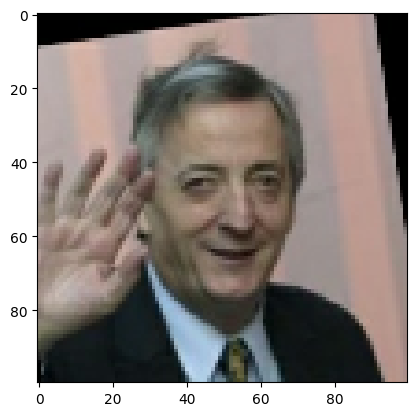

In [38]:
# index 1 is negative image 
plt.imshow(samples.next()[1])

In [39]:
# Training partition
train_data = data.take(round(len(data)*.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [40]:
# confirm train_data shape and type after take/batch/prefetch
train_data

<PrefetchDataset shapes: ((None, 100, 100, None), (None, 100, 100, None), (None,)), types: (tf.float32, tf.float32, tf.float32)>

In [41]:
# confirm each train batch is a 3-tuple (anchor, validation, label)
train_samples = train_data.as_numpy_iterator()
len(train_samples.next())

3

In [42]:
# confirm batch size is 16 as expected
train_sample = train_samples.next()
len(train_sample[0])

16

In [43]:
# Testing partition
test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

## 4. Model Engineering

### 4.1 Build Embedding Layer

In [44]:
# the tutorial uses a 64×64 max-scan which costs far more computing time per output pixel than a 2×2 one (thank you Justin!)

def make_embedding(): 
    inp = Input(shape=(100,100,3), name='input_image')
    
    # First block: a single 100x100x3 face image (one half of a Siamese pair)
    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    # after max-pooling (2,2): spatial size halved, 91x91 to 46x46
    m1 = MaxPooling2D((2,2), padding='same')(c1)
    
    # Second block: second conv block: 7x7 filters, 128 channels, then pool halves size again
    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D((2,2), padding='same')(c2)
    
    # Third block: third conv block: 4x4 filters, still 128 channels, further shrinking spatial size 
    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D((2,2), padding='same')(c3)
    
    # Final embedding block: inal conv block: 4x4 filters, 256 channels for richer high-level features,
    # then flatten to a 1D vector and compress into the 4096-d embedding via dense+sigmoid
    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation='sigmoid')(f1)
    
    # wraps the full stack into a reusable model: input image in, 4096-d embedding out
    return Model(inputs=[inp], outputs=[d1], name='embedding')

In [45]:
# build the full embedding model and print its architecture summary

embedding = make_embedding()
embedding.summary()

Model: "embedding"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 100, 100, 3)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 91, 91, 64)        19264     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 46, 46, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 40, 40, 128)       401536    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 20, 20, 128)       0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 17, 17, 128)       262272    
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 9, 9, 128)         0 

### 4.2 Build Distance Layer

In [46]:
# Siamese L1 Distance class
class L1Dist(Layer):
    
    # Init method - inheritance
    def __init__(self, **kwargs):
        super().__init__()
       
    # similarity calculation
    def call(self, input_embedding, validation_embedding):
        return tf.math.abs(input_embedding - validation_embedding)

In [47]:
# instantiate the L1 distance layer
l1 = L1Dist()
# an example call to test L1Dist would be : l1(anchor_embedding, validation_embedding)

### 4.3 Make Siamese Model

In [48]:
# bring all the previous steps together and create the Siamese Model

In [49]:
def make_siamese_model(): 
    
    # Anchor image input in the network
    input_image = Input(name='input_img', shape=(100,100,3))
    
    # Validation image in the network 
    validation_image = Input(name='validation_img', shape=(100,100,3))
    
    # Combine siamese distance components: embed both inputs with the
    # shared embedding network, then measure their L1 distance
    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer(embedding(input_image), embedding(validation_image))
    
    # Classification layer : single sigmoid unit turns the distance vector
    # into a same/different probability between 0 and 1
    classifier = Dense(1, activation='sigmoid')(distances)
    
    # wraps both inputs and the classifier into one trainable end-to-end model
    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [50]:
# build the full Siamese model and print its architecture summary

siamese_model = make_siamese_model()
siamese_model.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
distance (L1Dist)               (None, 4096)         0           embedding[0][0]     

## 5. Training

### 5.1 Setup Loss and Optimizer

In [51]:
# standard loss for binary same/different classification

binary_cross_loss = tf.losses.BinaryCrossentropy()

In [52]:
# 0.0001 is the learning rate, common default for this size of network
    
opt = tf.keras.optimizers.Adam(1e-4)

### 5.2 Establish Checkpoints

In [53]:
# Establish checkpoints - allows resuming/saving trained weights periodically during training

checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(opt=opt, siamese_model=siamese_model)

### 5.3 Build Train Step Function

In [54]:
# Build train step function - runs one forward+backward pass on a single batch
# Wrapped in @tf.function so TensorFlow compiles it into a graph for faster execution

@tf.function
def train_step(batch):
    
    # Record all of our operations 
    with tf.GradientTape() as tape:     
        # Get anchor and positive/negative image
        X = batch[:2]
        # Get label
        y = batch[2]
        
        # Forward pass
        yhat = siamese_model(X, training=True)
        # Calculate loss
        loss = binary_cross_loss(y, yhat)
    print(loss)
        
    # Calculate gradients
    grad = tape.gradient(loss, siamese_model.trainable_variables)
    
    # Calculate updated weights and apply to siamese model
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))
        
    # Return loss
    return loss

### 5.4 Build Training Loop

In [55]:
# Import metric calculations
from tensorflow.keras.metrics import Precision, Recall

In [56]:
def train(data, EPOCHS):
    # Loop through epochs
    for epoch in range(1, EPOCHS+1):
        print('\n Epoch {}/{}'.format(epoch, EPOCHS))
        progbar = tf.keras.utils.Progbar(len(data))
        
        # Creating a metric object 
        r = Recall()
        p = Precision()
        
        # Loop through each batch
        for idx, batch in enumerate(data):
            # Run train step here
            loss = train_step(batch)
            yhat = siamese_model.predict(batch[:2])
            r.update_state(batch[2], yhat)
            p.update_state(batch[2], yhat) 
            progbar.update(idx+1)
        print(loss.numpy(), r.result().numpy(), p.result().numpy())
        
        # Save checkpoints
        if epoch % 10 == 0: 
            checkpoint.save(file_prefix=checkpoint_prefix)

### 5.5 Train the Model

In [57]:
# Train the model

EPOCHS = 50

In [58]:
train(train_data, EPOCHS) #4 min


 Epoch 1/50
Tensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)
Tensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)
39/39 [==============================] - 68s 857ms/step
0.053770747 0.9774194 0.9934426

 Epoch 2/50
39/39 [==============================] - 3s 86ms/step
0.021063687 0.9969419 1.0

 Epoch 3/50
39/39 [==============================] - 3s 86ms/step
0.0014233626 1.0 1.0

 Epoch 4/50
39/39 [==============================] - 3s 86ms/step
0.00011432249 1.0 1.0

 Epoch 5/50
39/39 [==============================] - 3s 87ms/step
0.00242329 1.0 1.0

 Epoch 6/50
39/39 [==============================] - 3s 86ms/step
1.2130396e-05 1.0 1.0

 Epoch 7/50
39/39 [==============================] - 3s 87ms/step
2.1216418e-05 1.0 1.0

 Epoch 8/50
39/39 [==============================] - 3s 87ms/step
4.493289e-05 1.0 1.0

 Epoch 9/50
39/39 [==============================] - 3s 89ms/step
1.2209804e-05 1.0 1.0

 Epoch 10/50
39/39 [=============

## 6. Evaluate Model

### 6.1 Import Metrics

In [59]:
# Import metric calculations
from tensorflow.keras.metrics import Precision, Recall

### 6.2 Make Predictions

In [60]:
# Get a batch of test data
test_input, test_val, y_true = test_data.as_numpy_iterator().next()

In [61]:
y_hat = siamese_model.predict([test_input, test_val])

In [62]:
# Post processing the results 
[1 if prediction > 0.5 else 0 for prediction in y_hat ]

[0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1]

In [63]:
y_true

array([0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 1.],
      dtype=float32)

### 6.3 Calculate Metrics

In [64]:
# Creating a metric object 
m = Recall()

# Calculating the recall value 
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

1.0

In [65]:
# Creating a metric object 
m = Precision()

# Calculating the precision value 
m.update_state(y_true, y_hat)

# Return precision Result
m.result().numpy()

1.0

In [66]:
# Evaluate precision and recall across the entire test set (not just one batch)

r = Recall()
p = Precision()

for test_input, test_val, y_true in test_data.as_numpy_iterator():
    yhat = siamese_model.predict([test_input, test_val])
    r.update_state(y_true, yhat)
    p.update_state(y_true,yhat) 

print(r.result().numpy(), p.result().numpy())

1.0 1.0


### 6.4 Visualize Results

In [67]:
# # Set plot size 
# plt.figure(figsize=(10,8))

# # Set first subplot
# plt.subplot(1,2,1)
# plt.imshow(test_input[0])

# # Set second subplot
# plt.subplot(1,2,2)
# plt.imshow(test_val[0])

# # Renders cleanly
# plt.show()

### 6.5 Enhanced Performance Evaluation (FNMR/FMR & Score Distribution)

In [103]:
# Collect raw similarity scores and true labels across the entire test set,
# needed to separate genuine vs impostor comparisons for the plots below

all_scores = []
all_labels = []

for test_input, test_val, y_true in test_data.as_numpy_iterator():
    yhat = siamese_model.predict([test_input, test_val])
    all_scores.extend(np.squeeze(yhat))
    all_labels.extend(y_true)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

genuine_scores = all_scores[all_labels == 1]
impostor_scores = all_scores[all_labels == 0]

print(f"Genuine comparisons: {len(genuine_scores)}, Impostor comparisons: {len(impostor_scores)}")

Genuine comparisons: 142, Impostor comparisons: 124


In [107]:
# check the data in genuine scores and imposter scores
print(len(genuine_scores), len(impostor_scores))
print(genuine_scores[:5], impostor_scores[:5])

# compute the histogram bin counts (this line was missing)
genuine_counts, genuine_edges = np.histogram(genuine_scores, bins=30, range=(-0.05, 1.05))
impostor_counts, impostor_edges = np.histogram(impostor_scores, bins=30, range=(-0.05, 1.05))

print("Genuine bin counts:", genuine_counts)
print("Impostor bin counts:", impostor_counts)

142 124
[0.9999999 1.        1.        0.9999956 0.9999194] [6.6329839e-09 1.0452568e-06 1.5462781e-10 7.7075485e-11 4.3593923e-10]
Genuine bin counts: [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0 142   0]
Impostor bin counts: [  0 124   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0]


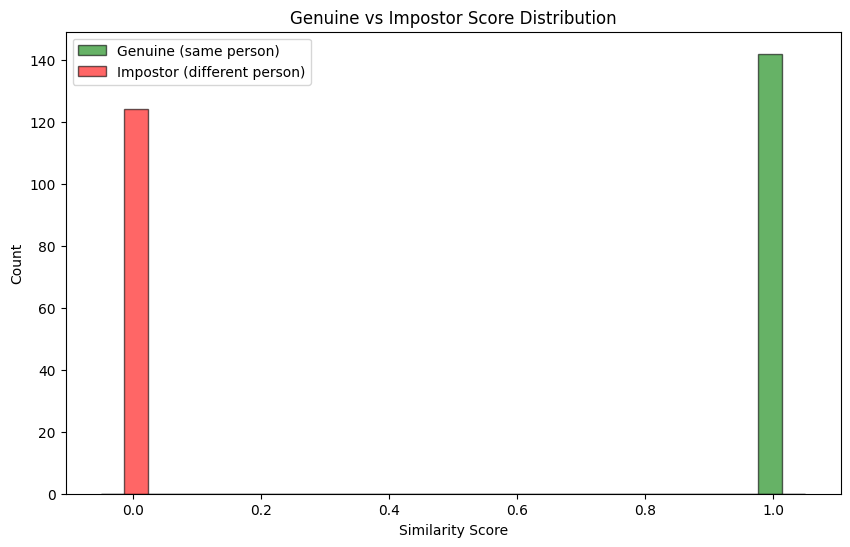

In [108]:
# genuine/impostor score histogram

plt.figure(figsize=(10, 6))
plt.hist(genuine_scores, bins=30, range=(-0.05, 1.05), alpha=0.6,
         label='Genuine (same person)', color='green', edgecolor='black')
plt.hist(impostor_scores, bins=30, range=(-0.05, 1.05), alpha=0.6,
         label='Impostor (different person)', color='red', edgecolor='black')
plt.xlabel('Similarity Score')
plt.ylabel('Count')
plt.title('Genuine vs Impostor Score Distribution')
plt.legend()
plt.show()

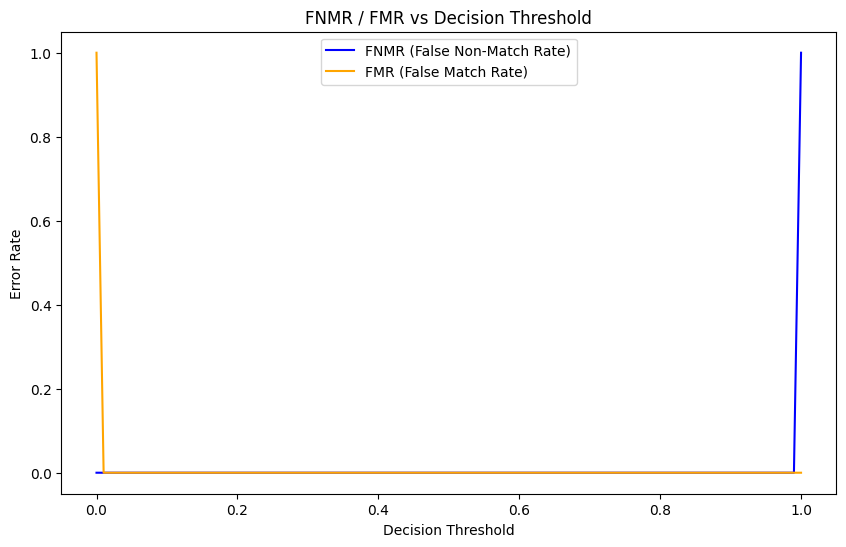

Approximate Equal Error Rate (EER): 0.0000 at threshold 0.01


In [109]:
thresholds = np.linspace(0, 1, 100)
fnmr_list = []
fmr_list = []

for t in thresholds:
    # False Non-Match Rate: genuine comparisons incorrectly rejected (score below threshold)
    fnmr = np.mean(genuine_scores <= t) if len(genuine_scores) > 0 else 0
    # False Match Rate: impostor comparisons incorrectly accepted (score above threshold)
    fmr = np.mean(impostor_scores > t) if len(impostor_scores) > 0 else 0
    fnmr_list.append(fnmr)
    fmr_list.append(fmr)

fnmr_list = np.array(fnmr_list)
fmr_list = np.array(fmr_list)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, fnmr_list, label='FNMR (False Non-Match Rate)', color='blue')
plt.plot(thresholds, fmr_list, label='FMR (False Match Rate)', color='orange')
plt.xlabel('Decision Threshold')
plt.ylabel('Error Rate')
plt.title('FNMR / FMR vs Decision Threshold')
plt.legend()
plt.show()

# Equal Error Rate: threshold where FNMR and FMR curves cross
eer_idx = np.argmin(np.abs(fnmr_list - fmr_list))
print(f"Approximate Equal Error Rate (EER): {(fnmr_list[eer_idx] + fmr_list[eer_idx]) / 2:.4f} "
      f"at threshold {thresholds[eer_idx]:.2f}")

**Interpretation:** The histogram shows complete separation between genuine scores ( around 142 comparisons, clustered at 1.0) and impostor scores (around 124 comparisons, clustered at 0.0), consistent with the 1.0/1.0 precision/recall from Section 6.3 and the near-zero Equal Error Rate above. This reflects strong generalization on this task (verified on held-out test data, not
training data), but the task itself: one identity vs. visually distinct LFW strangers is relatively easy; it does not test the model against visually similar or harder impostor cases.

## 7. Save Model

In [68]:
# Save weights
siamese_model.save('siamesemodelv2.h5')

In [69]:
# Reload model
# Note: "not compiled" warning is expected - training config isn't needed
# for inference-only use in Section 8 (real-time verification)

siamese_model = tf.keras.models.load_model('siamesemodelv2.h5', 
                                   custom_objects={'L1Dist':L1Dist, 'BinaryCrossentropy':tf.losses.BinaryCrossentropy})

In [70]:
# Make predictions with reloaded model
siamese_model.predict([test_input, test_val])

array([[1.1435040e-09],
       [1.0000000e+00],
       [2.9794218e-09],
       [2.5822239e-10],
       [1.0000000e+00],
       [8.3839886e-06],
       [1.0000000e+00],
       [1.0000000e+00],
       [9.9999988e-01],
       [9.9999976e-01]], dtype=float32)

In [71]:
# View model summary
siamese_model.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 100, 100, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
l1_dist_2 (L1Dist)              (None, 4096)         0           embedding[0][0]     

## 8. Real-Time Test

### 8.1 Verification Function

In [77]:
# create new directories  
os.makedirs('application_data/verification_images', exist_ok=True)
os.makedirs('application_data/input_image', exist_ok=True)

In [80]:
# sanity check: lists all files in verification_images
for image in os.listdir(os.path.join('application_data', 'verification_images')):
    validation_img = os.path.join('application_data', 'verification_images', image)
    print(validation_img)

application_data/verification_images/a9d0679f-8465-11f1-83e8-508492bbeca6.jpg:Zone.Identifier
application_data/verification_images/a9c2771e-8465-11f1-a0c1-508492bbeca6.jpg:Zone.Identifier
application_data/verification_images/a9cb90e7-8465-11f1-b6b3-508492bbeca6.jpg
application_data/verification_images/a9e669ac-8465-11f1-a89e-508492bbeca6.jpg
application_data/verification_images/a9e1c526-8465-11f1-9092-508492bbeca6.jpg:Zone.Identifier
application_data/verification_images/a9d541ef-8465-11f1-88e6-508492bbeca6.jpg
application_data/verification_images/a9dcebf7-8465-11f1-bb92-508492bbeca6.jpg:Zone.Identifier
application_data/verification_images/a9cb90e7-8465-11f1-b6b3-508492bbeca6.jpg:Zone.Identifier
application_data/verification_images/a9d0679f-8465-11f1-83e8-508492bbeca6.jpg
application_data/verification_images/a9e669ac-8465-11f1-a89e-508492bbeca6.jpg:Zone.Identifier
application_data/verification_images/a9c2771e-8465-11f1-a0c1-508492bbeca6.jpg
application_data/verification_images/a9d541ef-

In [96]:
# The core of the real-time check
# make sure you copy some of the positive data into the verification folder

## Exception handling added below Because anchor/positive/verification images in this project are captured on native Windows 
# (see Section 3 /README.md) and then copied into WSL via the `\\wsl$\...` network path rather than natively on Linux, 
# the destination folders can silently pick up stray non-image files from Windows Explorer (`desktop.ini`, `Thumbs.db`) 
# alongside the real `.jpg` files. `os.listdir()` returns these indiscriminately, and `tf.io.decode_jpeg()` throws an 
# `InvalidArgumentError` if it encounters one, this happened during development and crashed the entire verification run on
# a single bad file. The `verify()` function below therefore explicitly filters to real image extensions 
# and wraps each per-image comparison in its own try/except, so one bad file is skipped and reported rather than halting
# the whole chec

def verify(model, detection_threshold, verification_threshold):
    # Build results array
    results = []

    verification_dir = os.path.join('application_data', 'verification_images')
    input_image_path = os.path.join('application_data', 'input_image', 'input_image.jpg')

    # Exception handling confirm the input image exists before doing any work
    if not os.path.exists(input_image_path):
        raise FileNotFoundError(
            f"Input image not found at '{input_image_path}'. Capture or copy a "
            f"test photo there first (see README.md Section 3.2 / 8)."
        )

    # Exception handling confirm the verification folder exists and list its contents
    try:
        all_files = os.listdir(verification_dir)
    except OSError as error:
        raise RuntimeError(f"Could not read verification folder '{verification_dir}': {error}") from error

    # Only consider real image files - skips stray non-image files (e.g. desktop.ini,
    # Thumbs.db) that can end up in this folder after copying files via Windows Explorer
    valid_images = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not valid_images:
        raise RuntimeError(
            f"No valid image files (.jpg/.jpeg/.png) found in '{verification_dir}'. "
            f"Add a few reference photos of the enrolled person first."
        )

    for image in valid_images:
        image_path = os.path.join(verification_dir, image)

        # Exception handling skip any file that fails to preprocess (e.g. corrupted
        # or non-image file with a misleading extension) instead of crashing the whole run
        try:
            input_img = preprocess(input_image_path)
            validation_img = preprocess(image_path)
        except Exception as error:
            print(f"Warning: skipping '{image}' - could not preprocess ({error})")
            continue

        # Make Predictions
        try:
            result = model.predict(list(np.expand_dims([input_img, validation_img], axis=1)))
        except Exception as error:
            print(f"Warning: skipping '{image}' - model prediction failed ({error})")
            continue

        results.append(result)

    # Exception handling if every comparison was skipped, there is nothing to verify
    if not results:
        raise RuntimeError(
            "No valid comparisons could be made - all verification images failed to "
            "process. Check the files in 'application_data/verification_images'."
        )

    # Detection Threshold: Metric above which a prediciton is considered positive
    detection = np.sum(np.array(results) > detection_threshold)

    # Verification Threshold: Proportion of positive predictions / total valid comparisons
    verification = detection / len(results)
    verified = verification > verification_threshold

    return results, verified

### 8.2 OpenCV Real-Time Verification

In [83]:
# works out of the box on native Windows or Linux (not WSL2)
# Kept here commented out for reference. See README.md Section 5.

# cap = cv2.VideoCapture(4)
# while cap.isOpened():
#     ret, frame = cap.read()
#     frame = frame[120:120+250,200:200+250, :]
    
#     cv2.imshow('Verification', frame)
    
#     # Verification trigger
#     if cv2.waitKey(10) & 0xFF == ord('v'):
#         # Save input image to application_data/input_image folder 
# #         hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
# #         h, s, v = cv2.split(hsv)

# #         lim = 255 - 10
# #         v[v > lim] = 255
# #         v[v <= lim] -= 10
        
# #         final_hsv = cv2.merge((h, s, v))
# #         img = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)

#         cv2.imwrite(os.path.join('application_data', 'input_image', 'input_image.jpg'), frame)
#         # Run verification
#         results, verified = verify(siamese_model, 0.5, 0.5)
#         print(verified)
    
#     if cv2.waitKey(10) & 0xFF == ord('q'):
#         break
# cap.release()
# cv2.destroyAllWindows()

In [86]:
# WSL2 WORKAROUND: live capture unreliable here (README.md Section 5).
# Instead: capture a single verification frame on native Windows using
# capture_images.py's approach, copy it into application_data/input_image/
# as input_image.jpg, then just run verification directly on that static image.
input_image_path = os.path.join('application_data', 'input_image', 'input_image.jpg')
assert os.path.exists(input_image_path), (
    "input_image.jpg not found - capture a frame on native Windows and copy it here first "
    "(see README.md Section 3.2 / 5 for the same workflow used for anchor/positive images)."
)

results, verified = verify(siamese_model, 0.5, 0.5)
print(verified)

True


In [87]:
np.sum(np.squeeze(results) > 0.9)

7

In [88]:
results

[array([[0.9999993]], dtype=float32),
 array([[0.9999981]], dtype=float32),
 array([[0.9999989]], dtype=float32),
 array([[0.99999917]], dtype=float32),
 array([[0.9999994]], dtype=float32),
 array([[0.9999982]], dtype=float32),
 array([[0.99999833]], dtype=float32)]

## 9. Final Verification Test

### 9.1 Genuine Test 

In [118]:
# Verify a genuine photo of yourself against the reference images.
# Expected result: verified == True

genuine_input_path = os.path.join('application_data', 'input_image', 'input_image.jpg')
assert os.path.exists(genuine_input_path), (
    "input_image.jpg not found - capture/copy a genuine photo of yourself here first "
    "(see README.md Section 3.2 / 5)."
)

# commented for privacy reasons
# plt.imshow(preprocess(genuine_input_path))
# plt.title('Genuine test input')
# plt.show()

genuine_results, genuine_verified = verify(siamese_model, 0.5, 0.5)
print(f"Genuine match test - verified: {genuine_verified}")
print(f"Individual similarity scores: {np.squeeze(genuine_results)}")

Genuine match test - verified: True
Individual similarity scores: [0.9999999  1.         1.         1.         0.99999976 1.
 1.        ]


### 9.2 Disguise Test (Wig + Sunglasses)

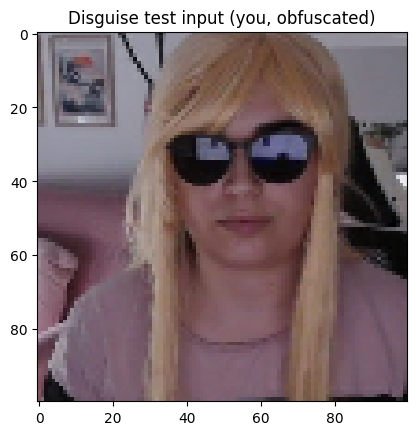

Disguise test - verified: False
Individual similarity scores: [0.2327545  0.11416665 0.1771979  0.21392119 0.2606063  0.11886058
 0.12703012]


In [116]:
# Test verification against an obfuscated version of yourself (wig + sunglasses)
# rather than a completely different person. This is a harder, more realistic test
# facial features (hair, eyes/eyebrows) are hidden, rather than just rejecting an obviously different face.

disguise_input_path = os.path.join('application_data', 'input_image', 'disguise_test.jpg')
assert os.path.exists(disguise_input_path), (
    "disguise_test.jpg not found - capture a photo of yourself wearing the "
    "disguise (e.g. wig, sunglasses) and save it here first."
)

backup_path = os.path.join('application_data', 'input_image', 'input_image_backup.jpg')
shutil.copy(genuine_input_path, backup_path)

try:
    shutil.copy(disguise_input_path, genuine_input_path)

    plt.imshow(preprocess(genuine_input_path))
    plt.title('Disguise test input (you, in disguise)')
    plt.show()

    disguise_results, disguise_verified = verify(siamese_model, 0.5, 0.5)
    print(f"Disguise test - verified: {disguise_verified}")
    print(f"Individual similarity scores: {np.squeeze(disguise_results)}")
finally:
    shutil.copy(backup_path, genuine_input_path)
    os.remove(backup_path)

**Interpretation:** Unlike the clean genuine/impostor separation in Section 6.5, this result is more revealing: the model rejected an obfuscated photo of the enrolled person themselves (`verified: False`, scores 0.12-0.26). This shows the model's near-perfect performance elsewhere is task-dependent. It has learned to recognize the person under normal, unobstructed conditions, but a wig and sunglasses (hiding hairline and eye region - likely important discriminative features for a network of this size and training set) is enough to push the comparison into "different person" territory. This is a genuine limitation, not a bug: LFW negatives and the anchor/positive captures used for training contain very little visual
disguise variation, so the model was never taught that obfuscated versions of the same person should still map close in embedding space. Addressing this would likely require training-time augmentation with occlusion/disguise examples, not just a threshold adjustment.

### 9.3 Imposter Test

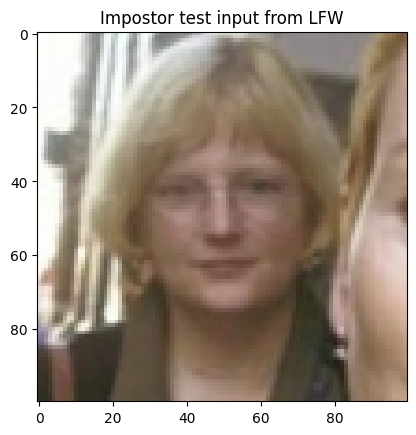

Impostor rejection test - verified: False
Individual similarity scores: [3.2113357e-07 2.7081337e-06 7.1357607e-07 4.8732215e-07 1.4264006e-07
 1.9204656e-06 1.1444426e-06]


In [95]:
# Temporarily swap input_image.jpg for a random LFW negative image 
# run verification, then restore the original genuine input_image.jpg afterwards.
# Expected result: verified == False
import random
import shutil

negative_dir = 'data/negative'
negative_files = [f for f in os.listdir(negative_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
assert negative_files, f"No negative images found in {negative_dir}"

impostor_source = os.path.join(negative_dir, random.choice(negative_files))
backup_path = os.path.join('application_data', 'input_image', 'input_image_backup.jpg')

# Back up the genuine input image before overwriting it
shutil.copy(genuine_input_path, backup_path)

try:
    shutil.copy(impostor_source, genuine_input_path)

    plt.imshow(preprocess(genuine_input_path))
    plt.title('Impostor test input from LFW')
    plt.show()

    impostor_results, impostor_verified = verify(siamese_model, 0.5, 0.5)
    print(f"Impostor rejection test - verified: {impostor_verified}")
    print(f"Individual similarity scores: {np.squeeze(impostor_results)}")
finally:
    # Always restore the genuine input image, even if verification above raised an error
    shutil.copy(backup_path, genuine_input_path)
    os.remove(backup_path)